In [38]:
import numpy as np
import matplotlib.pyplot as plt

In [39]:
from PIL import Image
import urllib.request

In [40]:
def load_img(path, side): # Load and process images into a binary array, where pixels are represented as 1 or -1
    urllib.request.urlretrieve(path,"my.png")
    img = Image.open("my.png")
    img = img.resize((side, side))
    img = img.convert('1')
    img = 2 * np.array(img, int) - 1
    return img.flatten()

def show_array(img_array): # Visualize images(array)
    side = int(np.sqrt(img_array.shape[0]))
    img_array = img_array.reshape((side, side))
    plt.figure(figsize=(3, 3))
    plt.imshow(img_array)
    plt.axis('off')
    plt.show()

def show_multiple_arrays(img_arrays):
    fig = plt.figure(figsize=(3, 3))
    for i in range(len(img_arrays)):
        side = int(np.sqrt(img_arrays[i].shape[0]))
        plt.subplot(1, len(img_arrays), i+1)
        plt.imshow(img_arrays[i].reshape((side, side)))
        plt.axis('off')
    plt.show()

In [4]:
# weights matrix
def calculate_w(img): # Create a weight matrix using the Hebbian learning rule based on the outer product of the image vector.
    '''
    w = np.zeros((n,n))
    for i in range(n):
        for j in range(n):
            if i != j:
                w[i,j] = img[i] * img[j]
    '''
    return np.outer(img, img)

In [41]:
# reconstruct image
def reconstructed_image(n, w, state): # Use the weight matrix to reconstruct an image from a modified or noisy version
    for i in range(n):
        sum = 0
        for j in range(n):
            sum += w[i,j] * state[j]
        state[i] = 1 if sum > 0 else -1
    return state
    # return np.dot(w, state)

memorized images:


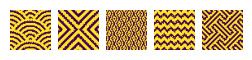

In [42]:
#multile patterns memory
side = 50
n = side * side #number of neurons(pixels)

N = 10;

#memory images
imgs=[]
for i in range(1,6): #memorize images from 1 to x-1
    imgs.append(load_img(f'https://raw.githubusercontent.com/uqglmn/ml/refs/heads/main/p{i}.png', side))

#weights matrix
w = np.zeros((n,n))
for p in range(len(imgs)):
    w+=calculate_w(imgs[p])

print('memorized images:')
show_multiple_arrays(imgs)

In [44]:
def half_img(n, img): 
    # Make 50% of image negative
    for i in range(n):
        if i > n / 2 - 1:
            img[i] = -1
    return img

def noise_img(n, img, k): # Introduce noise or modifications to an image, for testing the network’s ability to reconstruct it
    indices = np.random.choice(n, size=k, replace=False)
    random_values = np.random.choice([-1, 1], size=k)
    img[indices] = random_values
    return img

init state:


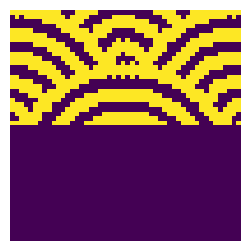

reconstructed image:


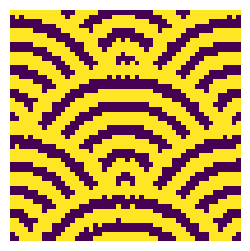

In [45]:
#set inital state
state = half_img(n, imgs[0].copy()) #modified image

print('init state:')
show_array(state)

#reconstruct image
state = reconstructed_image(n, w, state)
print('reconstructed image:')
show_array(state)

init state:


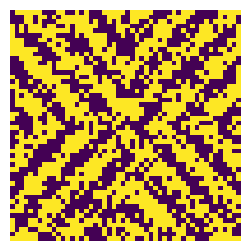

reconstructed image:


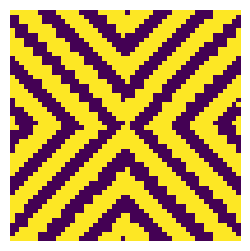

In [50]:
# set noise level
noise = 1000

#set inital state
state = noise_img(n, imgs[1].copy(), noise) #modified image

print('init state:')
show_array(state)

#reconstruct image
state = reconstructed_image(n, w, state)
print('reconstructed image:')
show_array(state)